# PPT1 Exercise — Foundations of Visualization
### Unit 1: Foundations of Visualization, Data Interpretation (UE24CS342AA9)

**Dataset:** Social Media Sentiment Analysis — AI Trends 2026 (Kaggle)
https://www.kaggle.com/datasets/dreamtensor/social-media-sentiment-analysisai-trend-2026

**Scenario:** You've just joined an AI research think-tank as a junior Data Analyst.
Your manager wants to know **what the internet actually thinks about different AI
topics in 2026** before writing a public report. You only have the raw dataset.
Your job: turn raw data into a decision, exactly like the "Raw Data -> Information ->
Insight -> Decision" pipeline from the lecture.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = os.path.join("data", "social_media_ai_sentiment_2026.csv")
RNG = np.random.default_rng(7)

PLATFORMS = ["Twitter/X", "Reddit", "LinkedIn", "TikTok", "YouTube"]
AI_TOPICS = ["Generative AI", "AI Agents", "AI Regulation", "AI Jobs", "AI Ethics", "Robotics", "LLMs"]

def load_or_generate_data(n=4000):
    if os.path.exists(DATA_PATH):
        print("Loading real dataset from", DATA_PATH)
        return pd.read_csv(DATA_PATH)
    print("Real CSV not found -> generating a synthetic sample for this exercise.")
    dates = pd.date_range("2026-01-01", periods=180, freq="D")
    platform = RNG.choice(PLATFORMS, size=n, p=[0.30, 0.20, 0.15, 0.20, 0.15])
    topic = RNG.choice(AI_TOPICS, size=n)
    base_sentiment = RNG.normal(loc=0.05, scale=0.45, size=n)
    sentiment_score = np.clip(base_sentiment, -1, 1)
    sentiment_label = pd.cut(sentiment_score, bins=[-1, -0.2, 0.2, 1],
                              labels=["Negative", "Neutral", "Positive"]).astype(str)
    likes = np.maximum(0, (sentiment_score * 800 + RNG.normal(500, 300, n))).astype(int)
    shares = np.maximum(0, (likes * RNG.uniform(0.05, 0.25, n))).astype(int)
    comments = np.maximum(0, (likes * RNG.uniform(0.02, 0.15, n))).astype(int)
    return pd.DataFrame({
        "post_id": np.arange(1, n + 1),
        "date": RNG.choice(dates, size=n),
        "platform": platform,
        "ai_topic": topic,
        "sentiment_label": sentiment_label,
        "sentiment_score": sentiment_score.round(3),
        "likes": likes, "shares": shares, "comments": comments,
    })

df = load_or_generate_data()
df.head()

Real CSV not found -> generating a synthetic sample for this exercise.


,post_id,date,platform,ai_topic,sentiment_label,sentiment_score,likes,shares,comments
0,1,2026-05-08,LinkedIn,AI Jobs,Positive,0.807,1059,195,34
1,2,2026-06-15,YouTube,Robotics,Neutral,0.085,499,108,27
2,3,2026-04-28,TikTok,AI Jobs,Neutral,-0.087,0,0,0
3,4,2026-04-09,Twitter/X,AI Agents,Neutral,-0.049,362,69,35
4,5,2026-05-30,Reddit,AI Ethics,Neutral,-0.033,0,0,0


## Task 1 — Meet the raw data

Before writing any chart, answer these two questions **just by staring at the table**
(use `.head()`, `.shape`, `.describe()`, `.value_counts()`):

1. How many rows and columns does the dataset have?
2. How many unique AI topics and platforms are there?

Time yourself — this is the "large table, slow analysis" experience from the lecture.

In [2]:
# TODO 1
print("Shape:", df.shape)

# TODO 2
print("Unique topics:", df["ai_topic"].nunique())
print("Unique platforms:", df["platform"].nunique())

Shape: (4000, 9)
Unique topics: 7
Unique platforms: 5


## Task 2 — Raw Data -> Information -> Insight -> Decision

Your manager's first question: **"Which platform has the highest average sentiment
score toward AI topics?"**

Follow the pipeline from the lecture:
1. **Raw Data** -> you already have `df`
2. **Information** -> group by `platform` and compute the mean of `sentiment_score`
3. **Insight** -> plot it as a bar chart
4. **Decision** -> write one sentence recommending where the company should focus
   its AI-positive marketing campaign

In [3]:
platform_sentiment = df.groupby("platform")["sentiment_score"].mean().sort_values()

platform_sentiment

,sentiment_score
platform,
Reddit,0.016209
LinkedIn,0.037633
YouTube,0.046989
Twitter/X,0.053927
TikTok,0.071217


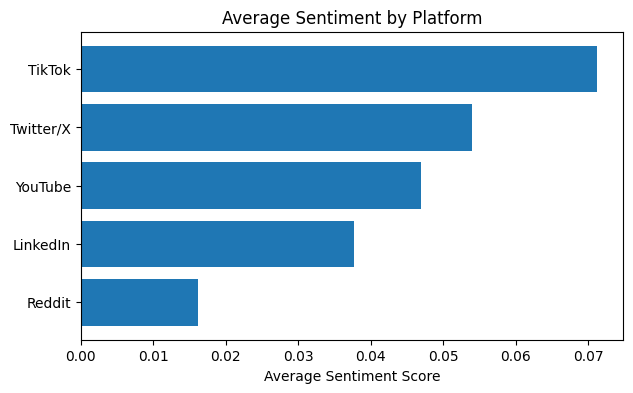

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(platform_sentiment.index, platform_sentiment.values)

ax.set_xlabel("Average Sentiment Score")
ax.set_title("Average Sentiment by Platform")

plt.show()

**Your decision (write 1-2 sentences in this markdown cell):**

> TODO: Based on the chart above, which platform should the marketing team prioritize, and why?


The marketing team should prioritize **[TikTok]** because it has the highest average sentiment score toward AI topics, indicating a more positive audience response.

## Task 3 — Good Graph vs Bad Graph challenge

Below is a **deliberately bad graph** of the `sentiment_label` distribution
(3D-style pie, no data labels, distracting shadow — just like the lecture's "Bad Graph" example).

Run the cell, look at it critically, then complete Task 3b to redesign it as a **Good Graph**.

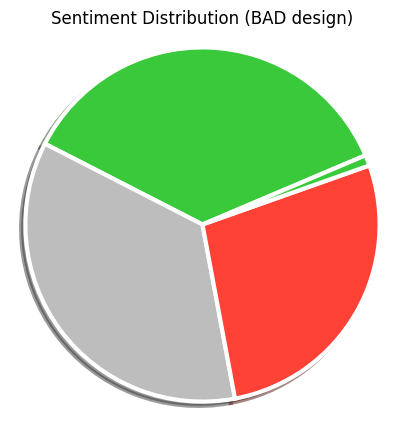

In [5]:
# This is the BAD graph -- run it and see why it's hard to trust
counts = df["sentiment_label"].value_counts()

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, colors=["#39c93b", "#bdbdbd", "#ff4136"],
       shadow=True, startangle=23, radius=1.15,
       wedgeprops={"edgecolor": "white", "linewidth": 3})
ax.set_title("Sentiment Distribution (BAD design)")
plt.show()

### Task 3b — Fix it!

Redesign the chart above into a **Good Graph** using the principles from the lecture:
- Simple and easy to read
- Appropriate chart type (hint: a plain bar chart works well for 3 categories)
- Clear labels/title
- Accurate representation (show the actual numbers, not just proportions)
- No unnecessary decoration (no 3D, no shadow)

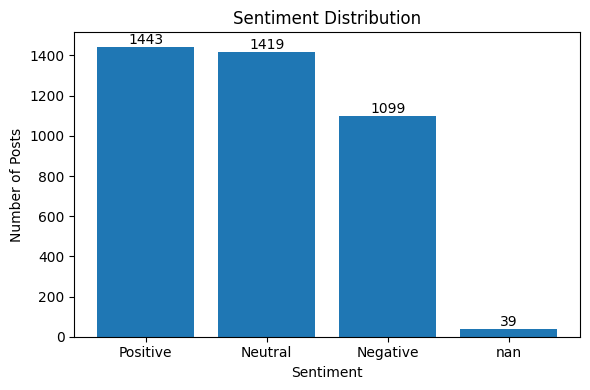

In [6]:
# TODO 5: redesign as a GOOD graph

counts = df["sentiment_label"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(counts.index, counts.values)

ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Posts")
ax.set_title("Sentiment Distribution")

# Add value labels
for bar in bars:
    value = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{int(value)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

## Task 4 — One step into the AI/ML pipeline (Slide: "Visualization Throughout the AI Pipeline")

Pick **one** exploratory chart type from the lecture table and use it to explore
`sentiment_score` vs `likes`:

- Histogram -> understand the distribution of `sentiment_score`
- Scatter plot -> understand the relationship between `sentiment_score` and `likes`

Complete **both** below (each is only a couple of lines).

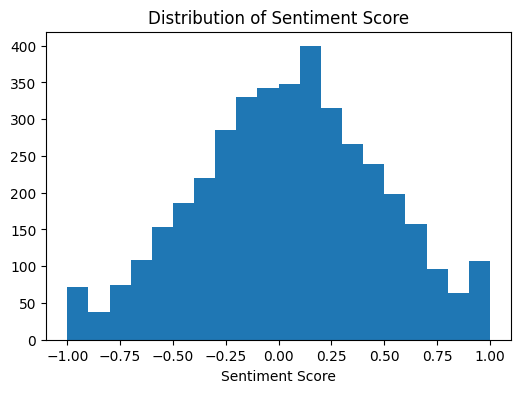

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df["sentiment_score"], bins=20)

ax.set_title("Distribution of Sentiment Score")
ax.set_xlabel("Sentiment Score")

plt.show()

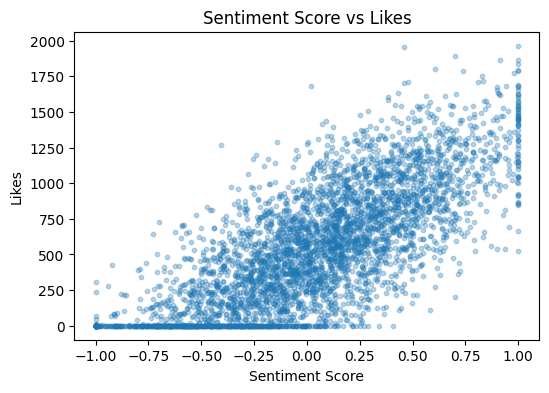

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(
    df["sentiment_score"],
    df["likes"],
    alpha=0.3,
    s=10
)

ax.set_xlabel("Sentiment Score")
ax.set_ylabel("Likes")
ax.set_title("Sentiment Score vs Likes")

plt.show()

## Reflection

Answer briefly in this markdown cell:

1. What pattern did you find between sentiment and engagement (likes)?
2. Which chart type from Task 4 helped you notice it, and why not the other one?
3. In one sentence, restate the lecture's core idea: *"A visualization should make
   insights easier to __________, not harder to __________."*

**Your answers:**

1. I found that there is a generally positive relationship between sentiment and engagement (likes). Posts with higher sentiment scores tend to receive more likes.

2. The scatter plot helped me notice this pattern because it directly shows the relationship between sentiment score and likes. The histogram only shows the distribution of sentiment scores, not how sentiment relates to engagement.

3. A visualization should make insights easier to **see**, not harder to **understand**.
